/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc
952
0


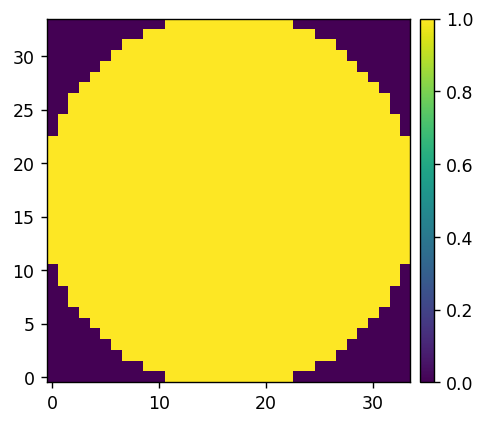

In [85]:
import numpy as np
import astropy.units as u
import threading as th
import time 
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
from IPython.display import clear_output
from importlib import reload
import copy
import os
from pathlib import Path

cwd = Path(os.getcwd())

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.patches import Circle, Rectangle

import scoob_llowfsc
print(scoob_llowfsc.path)
data_path = scoob_llowfsc.path/'exp-data'

import scoob_llowfsc.llowfsc as llowfsc
import scoob_llowfsc.scoob_interface as scoobi
import scoob_llowfsc.utils as utils
import scoob_llowfsc.telem as telem
from scoob_llowfsc.math_module import xp, xcipy, ensure_np_array
from scoob_llowfsc.imshows import imshow

from magpyx.utils import ImageStream
import purepyindi
from purepyindi import INDIClient
import purepyindi2
from purepyindi2 import IndiClient

client0 = INDIClient('localhost', 7624)
client0.start()
client = IndiClient()
client.connect()
client.get_properties()

def restart_clients():
    client0 = INDIClient('localhost', 7624)
    client0.start()

    client = IndiClient()
    client.connect()
    client.get_properties()

wavelength = 633e-9

dm_mask = ensure_np_array(scoobi.make_dm_mask())
print(dm_mask.sum())
imshow([dm_mask])


In [2]:
reload(telem)

exp_path = data_path/f'exp-{today}'
llowfsc_data_path = data_path/f'exp-{today}'/'llowfsc'
telem.make_dir(exp_path)
telem.make_dir(llowfsc_data_path)

Directory '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250320' created successfully.
Directory '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250320/llowfsc' created successfully.


In [161]:
reload(scoobi)
scoobi.set_camlo_roi(xc=2574, vcropoffset=1833, client=client0)

Set CAMLO ROI.


In [ ]:
reload(scoobi)
camlo_blacklevel = 100
camlo_gain = 120
camlo_exp_time = .1e-3

scoobi.set_camlo_blacklevel(camlo_blacklevel, client0)
scoobi.set_camlo_gain(camlo_gain, client0)
scoobi.set_camlo_exp_time(camlo_exp_time, client0)

Set the fiber attenuation to 2.5
Set CAMLO blacklevel.
Set the CAMLO gain setting to 120.0
Set the CAMLO exposure time to 1.00e-04s


# Initialize streams and create required shmims.

In [133]:
camlo_stream = ImageStream('camnsv')
camlo_dims = (128, 128)

camlo_ref_channel = 'camlo_ref_0'
camlo_ref_offset_channel = 'camlo_ref_offset'

scoobi.create_shmim(camlo_ref_channel, camlo_dims)
scoobi.create_shmim(camlo_ref_offset_channel, camlo_dims)

camlo_ref_stream = ImageStream(camlo_ref_channel)
camlo_ref_offset_stream = ImageStream(camlo_ref_offset_channel)

dm_lo_channel = 'dm00disp02'
dm_ho_channel = 'dm00disp03' 
dm_lo_stream = ImageStream(dm_lo_channel)
dm_dh_stream = ImageStream(dm_ho_channel)

INFO:utils:Got semaphore index 1.


0


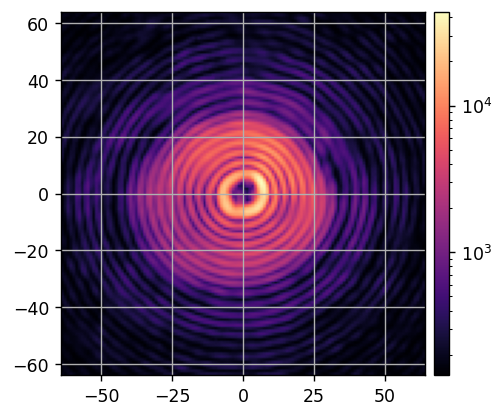

In [134]:
ref_im = np.mean( camlo_stream.grab_many(200), axis=0)
imshow([ref_im], grids=[1], pxscls=[1], norms=[LogNorm()], cmaps=['magma'])

1


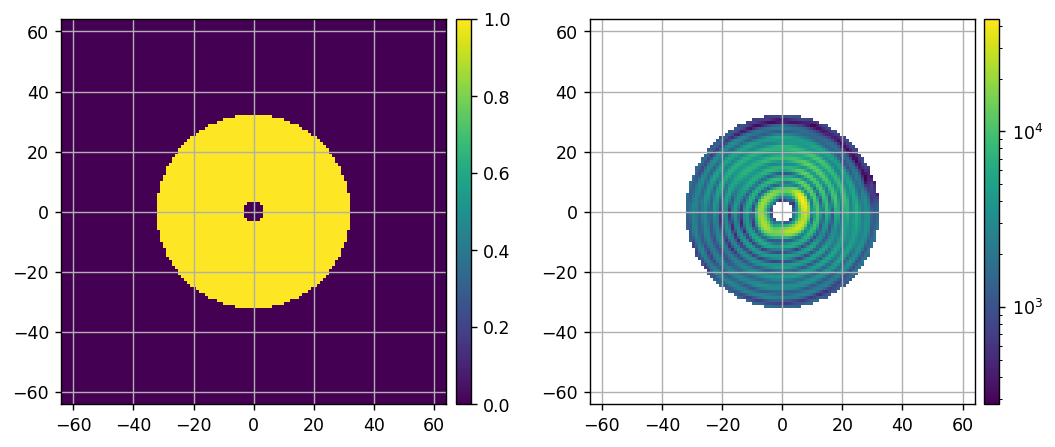

In [135]:
irad = 3
orad = 32
control_mask = llowfsc.create_control_mask(
    camlo_dims, 
    irad, 
    orad, 
    x_shift=0,
    y_shift=0,
    even=1,
)
# control_mask = xp.ones((M.nlocam, M.nlocam)).astype(bool)
imshow([control_mask, ref_im * control_mask], grids=[1, 1], pxscls=[1, 1], norms=[None, LogNorm()])

In [136]:
camlo_ref_stream.write(ref_im*control_mask)

# Calibrate LLOWFSC with the Zernike modes we want to control

1


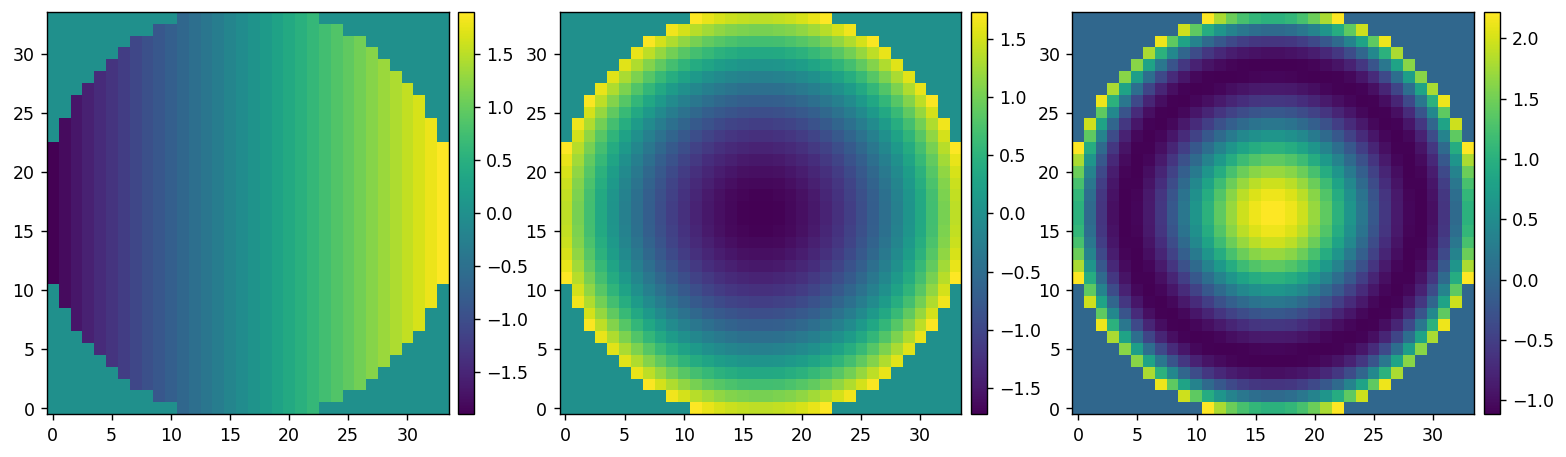

In [137]:
reload(scoobi)
reload(utils)
Nz_modes = 10
zer_modes = ensure_np_array(utils.create_zernike_modes(dm_mask, nmodes=Nz_modes, remove_modes=1))
zer_modal_matrix = zer_modes.reshape(Nz_modes, -1)
imshow([zer_modes[0], zer_modes[2], zer_modes[-1]])

1


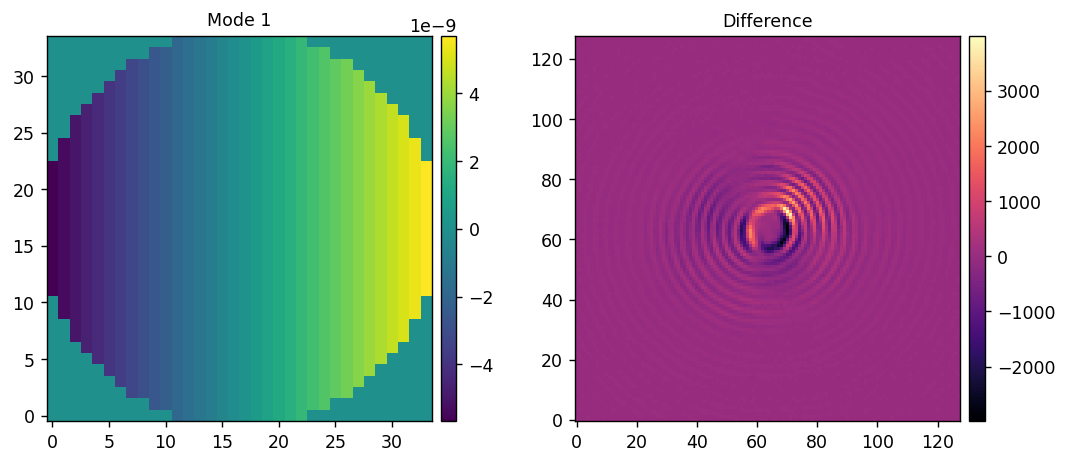

1Calibrated mode 1/10 in 3.198s


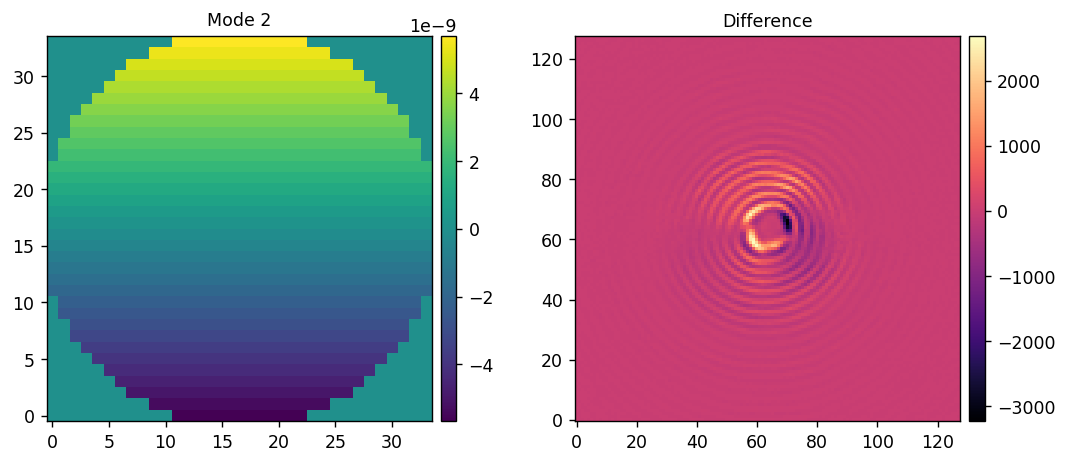

1Calibrated mode 2/10 in 6.127s


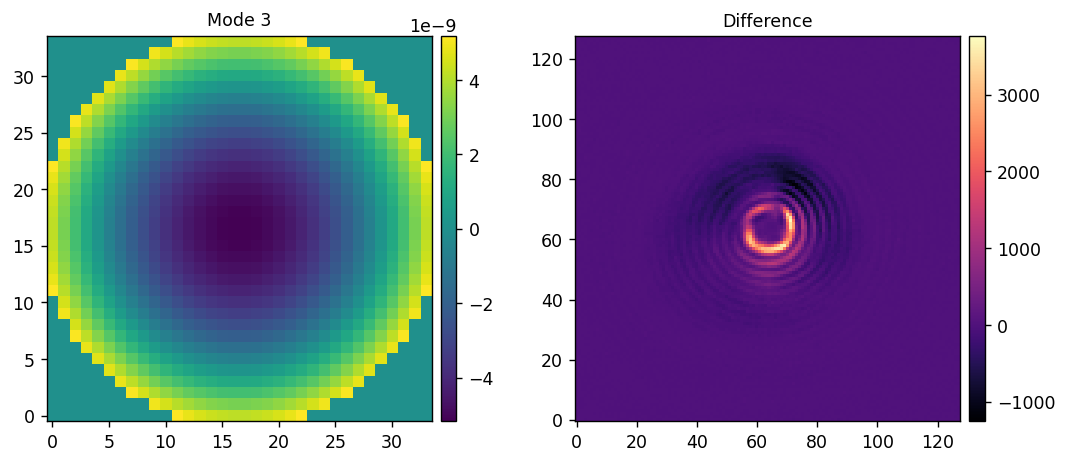

1Calibrated mode 3/10 in 8.798s


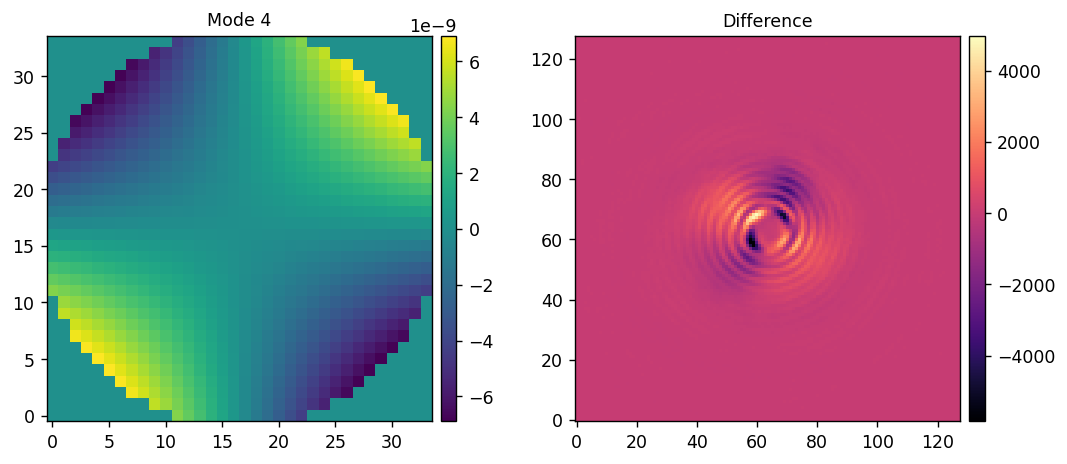

1Calibrated mode 4/10 in 11.726s


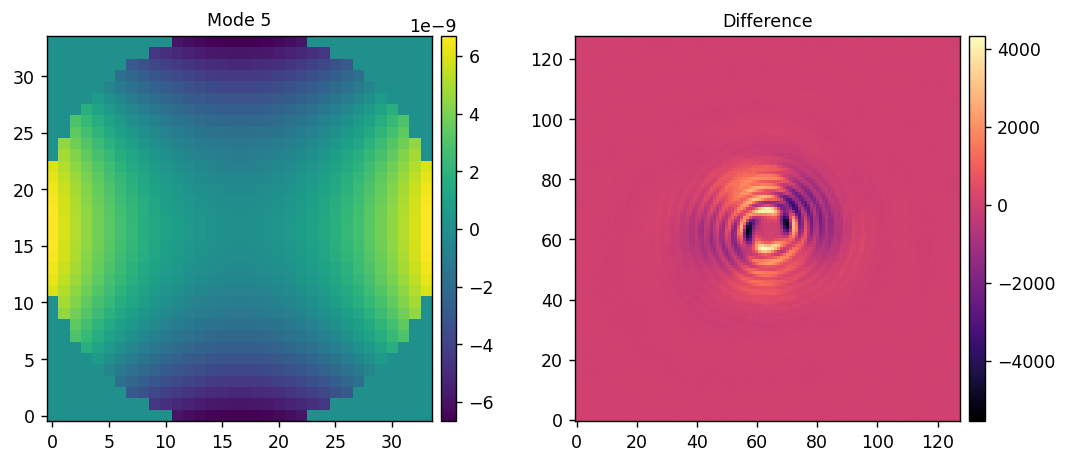

1Calibrated mode 5/10 in 14.717s


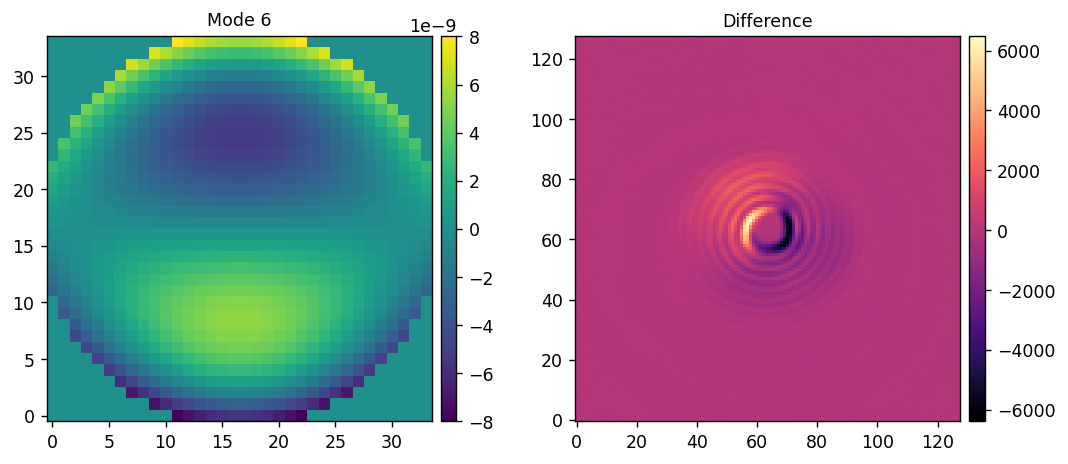

1Calibrated mode 6/10 in 17.646s


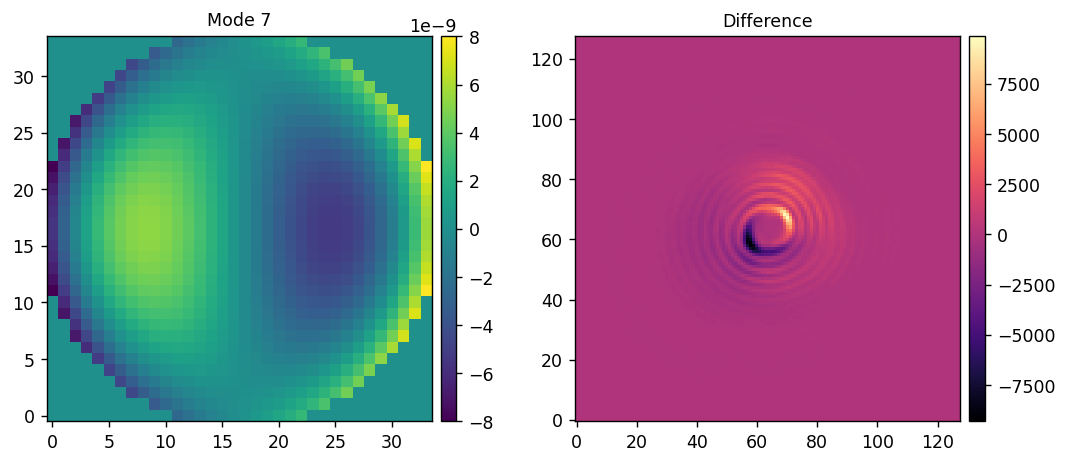

1Calibrated mode 7/10 in 20.809s


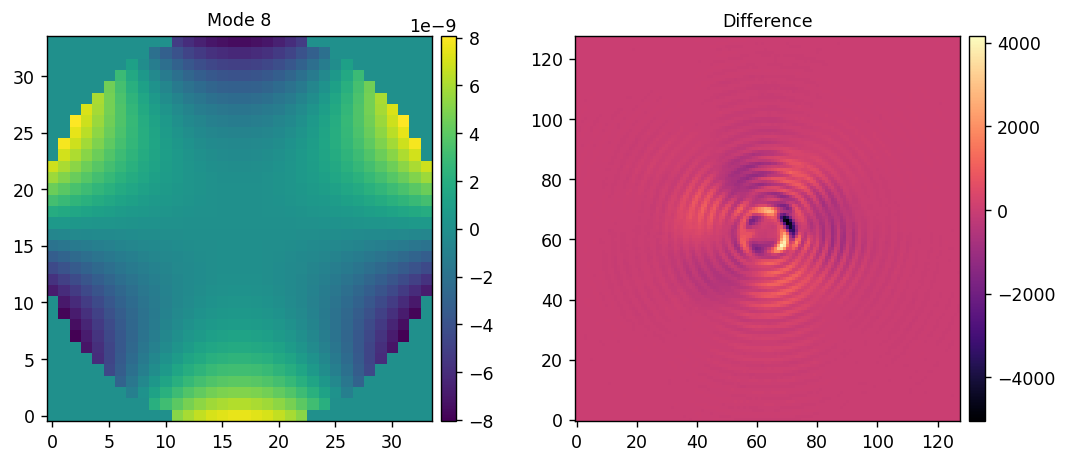

1Calibrated mode 8/10 in 23.567s


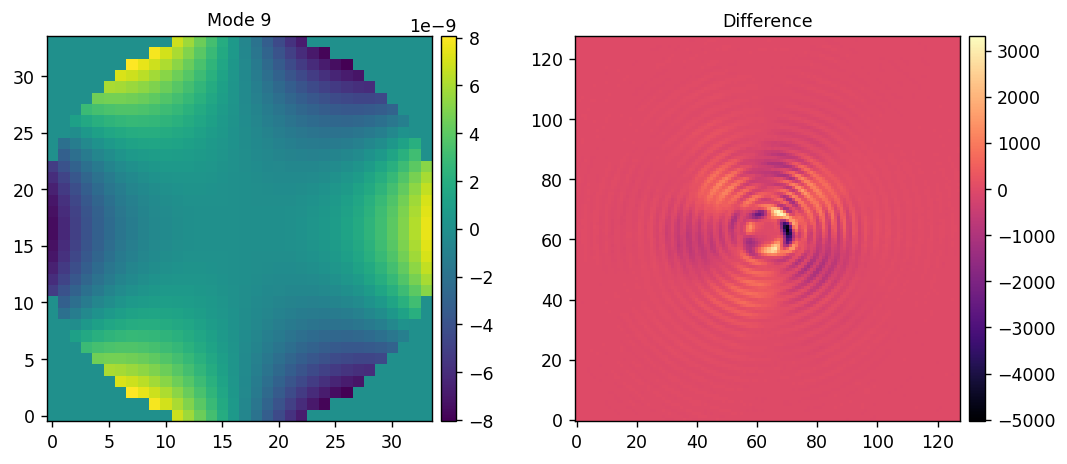

1Calibrated mode 9/10 in 26.445s


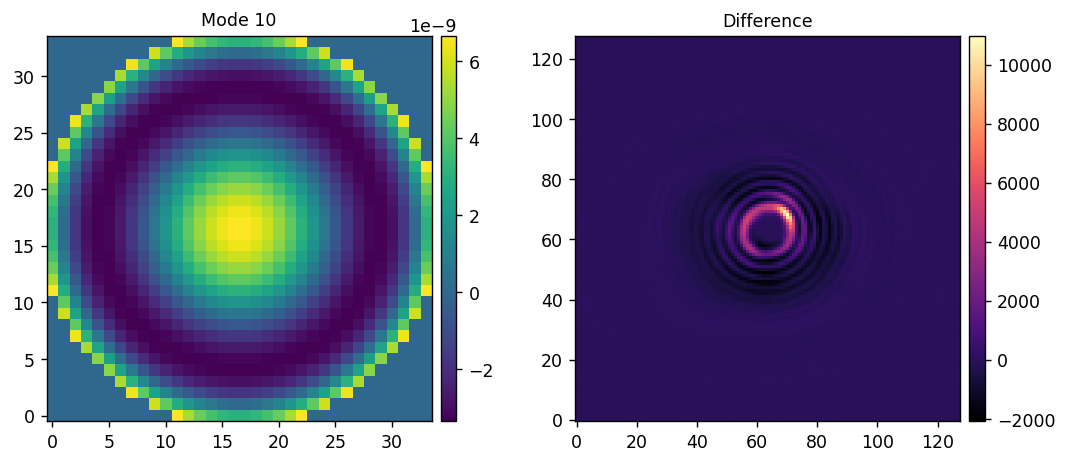

In [138]:
reload(llowfsc)
zer_calib_amp = 3e-9
zer_calib_nframes = 50

zer_response_matrix, zer_response_cube = llowfsc.calibrate_without_fsm(
    camlo_stream, 
    dm_lo_stream, 
    zer_modes, 
    control_mask, 
    amps=zer_calib_amp, 
    NFRAMES=zer_calib_nframes, 
    dm_delay=0.05, 
    plot=True,
)

In [141]:
zer_calib_data = {
    'response_matrix':zer_response_matrix,
    'response_cube':zer_response_cube,
    'modes':zer_modes, 
    'calib_amp':zer_calib_amp,
    'control_mask':control_mask,
    'NFRAMES':zer_calib_nframes,
    'camlo_exp_time':camlo_exp_time,
    'camlo_gain':camlo_gain,
}
utils.save_pickle(llowfsc_data_path/'zernike_calibration.pkl', zer_calib_data)

Saved data to:  /home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250320/llowfsc/zernike_calibration.pkl


In [ ]:
old_calib_path = data_path/f'exp-'/'llowfsc'/'zernike_calibration.pkl'
old_calib_data = utils.load_pickle(old_calib_path)

1


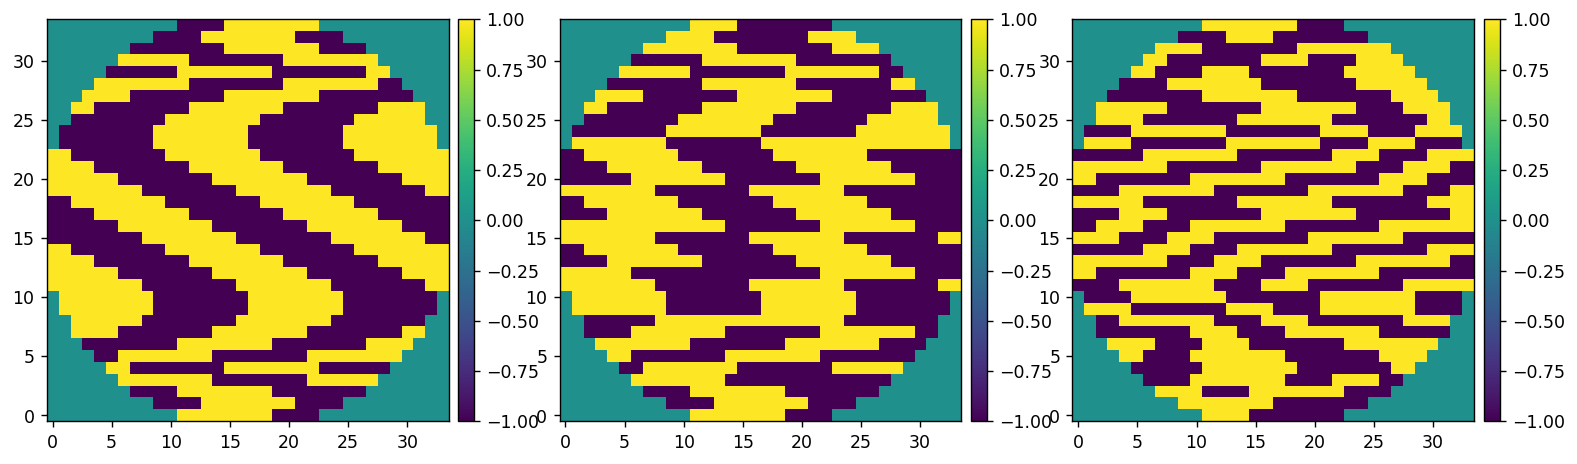

In [142]:
had_modes = ensure_np_array(utils.create_hadamard_modes(xp.array(dm_mask)))
had_modal_matrix = had_modes.reshape(had_modes.shape[0], -1)
imshow([had_modes[8], had_modes[200], had_modes[300]])

In [143]:
reload(llowfsc)

had_calib_amp = 3e-9
had_calib_nframes = 25

had_response_matrix, had_response_cube = llowfsc.calibrate_without_fsm(
    camlo_stream, 
    dm_lo_stream, 
    had_modes, 
    control_mask, 
    amps=had_calib_amp, 
    NFRAMES=had_calib_nframes, 
    dm_delay=0.05, 
    # plot=True,
)

In [144]:
had_calib_data = {
    'response_matrix':had_response_matrix,
    'response_cube':had_response_cube,
    'modes':had_modes,
    'calib_amp':had_calib_amp,
    'control_mask':control_mask,
    'NLOCAM':had_calib_nframes,
    'camlo_exp_time':camlo_exp_time,
    'camlo_gain':camlo_gain,
}
utils.save_pickle(llowfsc_data_path/'hadamard_calibration.pkl', had_calib_data)

Saved data to:  /home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250320/llowfsc/hadamard_calibration.pkl


# Define and run the reference offsetting process.

In [145]:
reload(scoobi)
reload(llowfsc)
reload(utils)

update_freq = 100
interval = 1/update_freq

args = [
    had_response_matrix, 
    had_modal_matrix, 
    control_mask, 
    dm_dh_stream, 
    camlo_ref_offset_stream,
]

ref_offset_process = llowfsc.Process(
    interval, 
    llowfsc.update_ref_offset, 
    args, # the args
)

In [146]:
ref_offset_process.start()

In [131]:
ref_offset_process.cancel()

In [148]:
dm_dh_stream.write(0.00 * had_modes[5])

# Define and run the LLOWFSC process.

In [149]:
lo_cm = ensure_np_array(utils.TikhonovInverse(xp.array(zer_response_matrix), 0))

gain_channel = 'llowfsc_gains'
leak_channel = 'llowfsc_leakage'
scoobi.create_shmim(gain_channel, (Nz_modes, 1))
scoobi.create_shmim(leak_channel, (1, 1)) # yes, it is a 1x1 array, shmims have to be this way

gains_stream = ImageStream(gain_channel)
leak_stream = ImageStream(leak_channel)
gains_stream.write(np.array([2*[0.5] + 8*[0.05],]))
leak_stream.write(np.array([[0.0]]))

In [156]:
reload(llowfsc)
reload(utils)

llowfsc_freq = 50
llowfsc_interval = 1/llowfsc_freq

args = [
    dm_lo_stream,
    camlo_stream,
    camlo_ref_stream,
    camlo_ref_offset_stream,  
    gains_stream,
    leak_stream, 
    lo_cm, 
    zer_modal_matrix, 
    control_mask, 
]

llowfsc_process = llowfsc.Process(
    1/llowfsc_freq, 
    llowfsc.single_iteration, 
    args, # the args
    # kwargs, # the kwargs
)



# Run the LLOWFSC process

In [157]:
# telem.toggle(1, 'camnsv', client0)
# telem.toggle(1, dm_lo_channel, client0)
llowfsc_process.start()

In [160]:
llowfsc_process.cancel()
dm_lo_stream.write(np.zeros(dm_lo_stream.shape))
# telem.toggle(0, 'camnsv', client0)
# telem.toggle(0, dm_lo_channel, client0)

## Adjust leakage and gains

In [159]:
leak_stream.write(np.array([[0.01]]))

In [158]:
gains_stream.write(np.array([2*[0.5] + 8*[0.05]]))

In [153]:
gains_stream.write(np.array([2*[0.75] + 3*[0.1] + 5*[0.1]]))

In [ ]:
gains_stream.write(np.array([2*[0.75] + 3*[0.2] + 5*[0.2]]))